In [39]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle, json



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,roc_auc_score, roc_curve)
from xgboost import XGBClassifier
import shap

In [40]:
data = pd.read_csv("healthcare-dataset-stroke-data.csv")

display(data.info(), data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


None

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [41]:
print(data.isnull().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


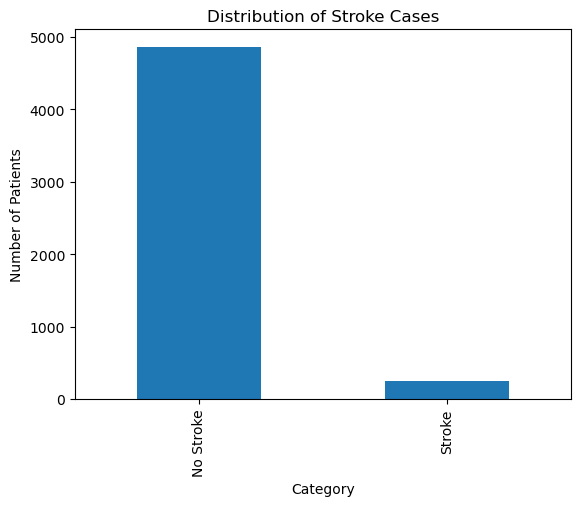

In [42]:
stroke_counts = data['stroke'].value_counts()

stroke_counts.index = ['No Stroke', 'Stroke']

stroke_counts.plot(kind='bar')

plt.title("Distribution of Stroke Cases")
plt.xlabel("Category")
plt.ylabel("Number of Patients")

plt.show()

In [43]:
data['bmi'] = data['bmi'].fillna(data['bmi'].mean())

print(data.isnull().sum())

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [44]:
data.drop(columns=['id'], inplace=True)

print(data.head())

   gender   age  hypertension  heart_disease ever_married      work_type  \
0    Male  67.0             0              1          Yes        Private   
1  Female  61.0             0              0          Yes  Self-employed   
2    Male  80.0             0              1          Yes        Private   
3  Female  49.0             0              0          Yes        Private   
4  Female  79.0             1              0          Yes  Self-employed   

  Residence_type  avg_glucose_level        bmi   smoking_status  stroke  
0          Urban             228.69  36.600000  formerly smoked       1  
1          Rural             202.21  28.893237     never smoked       1  
2          Rural             105.92  32.500000     never smoked       1  
3          Urban             171.23  34.400000           smokes       1  
4          Rural             174.12  24.000000     never smoked       1  


In [45]:
data.drop_duplicates(inplace=True)

print(data.shape)

(5110, 11)


In [46]:
data = data[data["smoking_status"] != 'Unknown']
data = data[data['gender'] != 'Other']
data.reset_index(drop=True, inplace=True)
print(data.shape)

(3565, 11)


In [47]:
data.to_csv("cleaned_data.csv", index=False)

In [48]:
categorical_cols = ['gender', 'ever_married', 'work_type',
                    'Residence_type', 'smoking_status']
numerical_cols   = ['age', 'hypertension', 'heart_disease',
                    'avg_glucose_level', 'bmi']

X = data.drop(columns=['stroke'])
y = data['stroke']

In [49]:
X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [50]:
preprocessor = ColumnTransformer(transformers=[
    ('onehot',  OneHotEncoder(drop='first', sparse_output=False), categorical_cols),
    ('scaler',  StandardScaler(),                                  numerical_cols)
], remainder='drop')

In [51]:
preprocessor.fit(X_raw_train)

,transformers,"[('onehot', ...), ('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,False


In [52]:
X_train = preprocessor.transform(X_raw_train)
X_test  = preprocessor.transform(X_raw_test)

In [53]:
encoded_featuree_names = (preprocessor.named_transformers_['onehot'].get_feature_names_out(categorical_cols).tolist())

In [54]:
print(encoded_featuree_names)

['gender_Male', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_never smoked', 'smoking_status_smokes']


In [55]:
all_feature_names = encoded_featuree_names + numerical_cols
print(all_feature_names)

['gender_Male', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_never smoked', 'smoking_status_smokes', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']


In [56]:
X_train = pd.DataFrame(X_train, columns=all_feature_names)
X_test  = pd.DataFrame(X_test,  columns=all_feature_names)

In [57]:
no_stroke_count = (y_train == 0).sum()
stroke_count = (y_train == 1).sum()

In [58]:
stroke_weight = round(no_stroke_count / stroke_count, 2)


In [59]:
#logistic regression
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [60]:
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [61]:
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)

In [62]:
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
xgb_model = XGBClassifier(n_estimators=200, weight_of_stroke=stroke_weight, use_label_encoder=False, eval_metric='logloss', random_state=42, verbosity=0)

In [64]:
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [65]:
os.makedirs('outputs', exist_ok=True)

In [66]:
def evaluate_model(name, model, X_test_data, Y_test_data):
    y_predictions = model.predict(X_test_data)
    y_probabilities = model.predict_proba(X_test_data)[:, 1]

    #evaluation metrics
    accuracy  = accuracy_score(Y_test_data, y_predictions)
    precision = precision_score(Y_test_data, y_predictions, zero_division=0)
    recall    = recall_score(Y_test_data, y_predictions, zero_division=0)
    f1 = f1_score(Y_test_data, y_predictions, zero_division=0)
    roc_auc   = roc_auc_score(Y_test_data, y_probabilities)
    confusion_mat = confusion_matrix(Y_test_data, y_predictions)
    true_neg, false_pos, false_neg, true_pos = confusion_mat.ravel()

    #print results
    print(f"\nModel: {name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'], ax=ax)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    safe = name.replace(' ', '_').lower()
    plt.savefig(f'outputs/confusion_matrix_{safe}.png', dpi=150)
    plt.close()

    return {
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        '_y_proba' : y_probabilities,
    }


In [67]:
evaluate_model("Logistic Regression", lr_model, X_test, y_test)
evaluate_model("Random Forest", rf_model, X_test, y_test)
evaluate_model("XGBoost", xgb_model, X_test, y_test)


Model: Logistic Regression
Accuracy: 0.7153
Precision: 0.1345
Recall: 0.7500
F1 Score: 0.2281
ROC-AUC: 0.8220

Model: Random Forest
Accuracy: 0.9439
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC-AUC: 0.7730

Model: XGBoost
Accuracy: 0.9313
Precision: 0.2000
Recall: 0.0750
F1 Score: 0.1091
ROC-AUC: 0.7559


{'Model': 'XGBoost',
 'Accuracy': 0.9312762973352033,
 'Precision': 0.2,
 'Recall': 0.075,
 'F1 Score': 0.10909090909090909,
 'ROC-AUC': 0.7559435364041605,
 '_y_proba': array([5.28771961e-05, 2.16034465e-02, 1.15193170e-03, 5.73919169e-05,
        9.14265029e-03, 1.04938095e-04, 3.86902876e-03, 1.80352315e-01,
        7.86936784e-04, 4.11006149e-05, 1.05576394e-02, 7.92194158e-02,
        6.21354394e-03, 3.92262154e-04, 1.15084043e-03, 7.53645785e-04,
        5.00533700e-01, 5.62037167e-04, 3.38568316e-05, 3.26921036e-05,
        4.56552807e-05, 8.47550452e-01, 5.11076069e-03, 4.31474873e-05,
        4.13543690e-04, 2.76296760e-05, 1.05830282e-03, 9.28816153e-05,
        9.47197026e-04, 6.48771937e-04, 1.75302557e-04, 9.21038154e-04,
        1.07364892e-03, 7.68795027e-04, 1.91558749e-04, 8.13115574e-03,
        3.98666525e-05, 1.17280339e-04, 3.53987003e-03, 9.46396403e-03,
        3.19206296e-03, 5.75546846e-06, 1.12426199e-03, 3.04760411e-02,
        1.47571254e-05, 3.85636376e-05,

In [68]:
results = []
results.append(evaluate_model("Logistic Regression", lr_model,  X_test, y_test))
results.append(evaluate_model("Random Forest",        rf_model,  X_test, y_test))
results.append(evaluate_model("XGBoost",              xgb_model, X_test, y_test))


Model: Logistic Regression
Accuracy: 0.7153
Precision: 0.1345
Recall: 0.7500
F1 Score: 0.2281
ROC-AUC: 0.8220

Model: Random Forest
Accuracy: 0.9439
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC-AUC: 0.7730

Model: XGBoost
Accuracy: 0.9313
Precision: 0.2000
Recall: 0.0750
F1 Score: 0.1091
ROC-AUC: 0.7559


In [69]:
for res in results:
    fig, ax = plt.subplots(figsize=(6, 5))

    fpr, tpr, _ = roc_curve(y_test, res['_y_proba'])

    ax.plot(fpr, tpr, lw=2,
            label=f"AUC = {res['ROC-AUC']:.4f}")

    # Diagonal line
    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC = 0.50)')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title(f"ROC Curve — {res['Model']}")
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

    plt.tight_layout()

    # Save each separately
    safe = res['Model'].replace(' ', '_').lower()
    plt.savefig(f'outputs/roc_curve_{safe}.png', dpi=150)

    plt.close()

In [70]:
results_clean = [{k: v for k, v in r.items() if not k.startswith('_')}
                 for r in results]
results_df = pd.DataFrame(results_clean).set_index('Model')

print("\n📊 Summary Table (all metrics including ROC-AUC):")
print(results_df.round(4).to_string())

best_model_name = results_df['Recall'].idxmax()
best_auc        = results_df.loc[best_model_name, 'ROC-AUC']
print(f"\n🏆 Best Model by Recall : {best_model_name}")
print(f"   ROC-AUC of best model : {best_auc:.4f}")



📊 Summary Table (all metrics including ROC-AUC):
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7153     0.1345   0.750    0.2281   0.8220
Random Forest          0.9439     0.0000   0.000    0.0000   0.7730
XGBoost                0.9313     0.2000   0.075    0.1091   0.7559

🏆 Best Model by Recall : Logistic Regression
   ROC-AUC of best model : 0.8220


In [71]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
results_df[metrics_to_plot].plot(kind='bar', figsize=(11, 6),
                                 colormap='tab10', edgecolor='black')
plt.title('Model Comparison — All Metrics (incl. ROC-AUC)', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150)
plt.close()

model_map  = {"Logistic Regression": lr_model,
              "Random Forest":        rf_model,
              "XGBoost":              xgb_model}
best_model = model_map[best_model_name]

In [72]:
sample_size = min(200, len(X_test))
X_sample    = X_test.iloc[:sample_size].reset_index(drop=True)

if best_model_name in ("Random Forest", "XGBoost"):
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.LinearExplainer(best_model, X_train,
                                     feature_perturbation="interventional")

shap_values = explainer.shap_values(X_sample)
shap_vals   = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure()
shap.summary_plot(shap_vals, X_sample, feature_names=all_feature_names, show=False)
plt.title(f'SHAP Summary Plot — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ SHAP summary plot    → outputs/shap_summary.png")

plt.figure()
shap.summary_plot(shap_vals, X_sample, feature_names=all_feature_names,
                  plot_type='bar', show=False)
plt.title(f'SHAP Feature Importance — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_importance.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ SHAP importance bar  → outputs/shap_importance.png")

mean_shap = np.abs(shap_vals).mean(axis=0)
feat_imp  = pd.Series(mean_shap, index=all_feature_names).sort_values(ascending=False)
print("\n📌 Top 10 Features by Mean |SHAP|:")
print(feat_imp.head(10).round(4).to_string())


C:\Users\FABUNMI\anaconda3\Lib\site-packages\shap\explainers\_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


✅ SHAP summary plot    → outputs/shap_summary.png
✅ SHAP importance bar  → outputs/shap_importance.png

📌 Top 10 Features by Mean |SHAP|:
age                            1.1688
gender_Male                    0.1645
work_type_Private              0.1639
smoking_status_never smoked    0.1441
avg_glucose_level              0.1325
hypertension                   0.1282
smoking_status_smokes          0.0947
work_type_Self-employed        0.0788
bmi                            0.0748
heart_disease                  0.0499


In [73]:
os.makedirs('model', exist_ok=True)

with open('model/best_model.pkl',       'wb') as f: pickle.dump(best_model,    f)
with open('model/preprocessor.pkl',     'wb') as f: pickle.dump(preprocessor,  f)
with open('model/feature_names.json',   'w')  as f: json.dump(all_feature_names, f)
with open('model/best_model_name.json', 'w')  as f: json.dump({'name': best_model_name}, f)

print(f"\n✅ model/best_model.pkl       — trained classifier")
print(f"✅ model/preprocessor.pkl     — fitted OHE + StandardScaler")
print(f"✅ model/feature_names.json   — feature list")
print(f"✅ model/best_model_name.json — selected model name")


✅ model/best_model.pkl       — trained classifier
✅ model/preprocessor.pkl     — fitted OHE + StandardScaler
✅ model/feature_names.json   — feature list
✅ model/best_model_name.json — selected model name
